# 03 · Dimension scaling of exact attribution

**Computes.** Exact recovery of first-order Shapley values on **synthetic single-$R_Y$ QNNs** for $d=4,6,8,10,12$. Exactness of the multilinear extension is weight- and instance-independent, so each QNN uses seed-fixed random weights and a random instance/baseline. At every $d$, Owen integration with $M=\lceil d/2\rceil$ reproduces exact $2^d$ enumeration to machine precision, while its cost $2d\lceil d/2\rceil$ separates sharply from $2^d$.

**Produces.** `figures/fig_cost.png` (paper panel (b)) and `results/03.json`.

**Seed.** Fixed per $d$ (QNN seed 0; instance/baseline seed $1000+d$).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import datasets, exact, owen, metrics
from tnshapq.io_utils import save_results, savefig

np.random.seed(0)
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 13,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11})
DIMS = [4, 6, 8, 10, 12]

In [2]:
# Exact recovery at each d (synthetic QNNs)
rows = []
for d in DIMS:
    qnn, x, baseline = datasets.synthetic_qnn(d)
    M = T.threshold_M(d, order=1)                 # ceil(d/2)
    phi_o, nq = owen.owen_integral_shapley(qnn, d, x, baseline, M)
    phi_e = exact.exact_shapley(exact.feature_value_table(qnn, d, x, baseline), d)
    err = metrics.max_abs_err(phi_o, phi_e)
    rows.append(dict(d=d, M=int(M), owen_evals=int(nq), enum_evals=int(2**d),
                     max_err=float(err)))
    print(f"d={d:2d}  M={M}  Owen evals={nq:4d}  vs 2^d={2**d:5d}  max|err|={err:.2e}")
all_exact = all(r["max_err"] < 1e-9 for r in rows)
print("all d exact:", all_exact)

d= 4  M=2  Owen evals=  16  vs 2^d=   16  max|err|=8.33e-17
d= 6  M=3  Owen evals=  36  vs 2^d=   64  max|err|=4.16e-17


d= 8  M=4  Owen evals=  64  vs 2^d=  256  max|err|=3.34e-17


d=10  M=5  Owen evals= 100  vs 2^d= 1024  max|err|=4.52e-17


d=12  M=6  Owen evals= 144  vs 2^d= 4096  max|err|=1.01e-16
all d exact: True


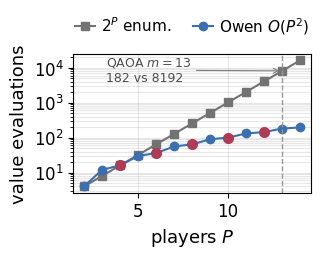

saved figures/fig_cost.png


In [3]:
# Cost curves: 2^P enumeration vs 2P*ceil(P/2) Owen; markers at validated d; QAOA m=13 ref
P = np.arange(2, 15)
enum = 2.0 ** P
owen_cost = 2 * P * np.ceil(P / 2)
m_gate, gate_owen, gate_enum = 13, 2 * 13 * int(np.ceil(13/2)), 2 ** 13   # 182 vs 8192

fig, ax = plt.subplots(figsize=(3.4, 2.8))
ax.semilogy(P, enum, 's-', color='0.45', label=r'$2^P$ enum.')
ax.semilogy(P, owen_cost, 'o-', color='#3b6fb0', label=r'Owen $O(P^2)$')
dv = np.array(DIMS)
ax.semilogy(dv, 2 * dv * np.ceil(dv / 2), 'o', color='#b03b54', ms=7, zorder=5)
ax.axvline(m_gate, color='0.6', ls='--', lw=1)
ax.annotate(f'QAOA $m{{=}}13$\n{gate_owen} vs {gate_enum}', xy=(m_gate, gate_enum),
            xytext=(3.2, 4e3), fontsize=9, color='0.3',
            arrowprops=dict(arrowstyle='->', color='0.5', lw=0.8))
ax.set_xlabel('players $P$')
ax.set_ylabel('value evaluations')

ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=2, columnspacing=1.4, handlelength=1.3, handletextpad=0.4); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
savefig(fig, 'fig_cost.png')
plt.show()
print("saved figures/fig_cost.png")

In [4]:
res = {
    "task": "dimension scaling (synthetic single-RY QNNs)",
    "dims": DIMS, "all_exact": bool(all_exact),
    "per_d": rows,
    "max_err_overall": float(max(r["max_err"] for r in rows)),
    "qaoa_ref": {"m": 13, "owen_evals": int(gate_owen), "enum_evals": int(gate_enum)},
}
save_results("03", res)
print("saved results/03.json")

saved results/03.json


In [5]:
# Verification: Owen M=ceil(d/2) matches 2^d enumeration at every d
for r in rows:
    assert r["max_err"] < 1e-9, f"d={r['d']} not exact ({r['max_err']:.2e})"
print("PASS  exact recovery at d =", DIMS)
print("      max error over all d =", f'{max(r["max_err"] for r in rows):.2e}')
print("      cost at d=12:", rows[-1]["owen_evals"], "Owen evals vs", rows[-1]["enum_evals"], "enumeration")

PASS  exact recovery at d = [4, 6, 8, 10, 12]
      max error over all d = 1.01e-16
      cost at d=12: 144 Owen evals vs 4096 enumeration
